# 550-inspired modeling lab: inspect the transformation

Six independent sections. Run the cells **within one section in order**, then pause to explain the outputs. Each section imports and creates what it needs and can run in a fresh kernel. All arrays are synthetic. No external files, internet access, MRI scans, neural-network packages, or pretrained weights are used. These demonstrations are not clinical models.

Use the companion `../lessons/550.md` for explanations, AI prompts, timing, exercises, and answer keys. All code here is original. Source attribution and access terms are in `../sources/550.md`.

Before each cell: predict its output shape and one expected result. After it: distinguish what was executed from what an assistant merely suggested. Every code cell is at most 20 lines.

## 1 — From toy voxels to regions to one connection

**Input → output:** `(120,6)` time-by-voxel values → `(120,2)` region means → `(2,2)` correlation. Regional averaging loses within-region variation. Correlation loses scale and offset, not pairwise linear association. These are two invented regions, not an atlas.

Predict: will multiplying the second region by five and adding ten change its correlation with the first?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(5501)
shared = np.sin(np.linspace(0, 6*np.pi, 120))
X = shared[:, None] + rng.normal(0, 0.3, (120, 6))
regions = np.column_stack([X[:, :3].mean(1), X[:, 3:].mean(1)])
C = np.corrcoef(regions, rowvar=False)
print("time×voxels, time×regions, correlation:", X.shape, regions.shape, C.shape)
print("correlation matrix:\n", C.round(3))
assert X.shape == (120, 6) and regions.shape == (120, 2)
assert np.allclose(C, C.T) and np.allclose(np.diag(C), 1)
assert np.all(np.abs(C) <= 1 + 1e-12)


time×voxels, time×regions, correlation: (120, 6) (120, 2) (2, 2)
correlation matrix:
 [[1.    0.948]
 [0.948 1.   ]]


Positive scaling and offset preserve correlation: True


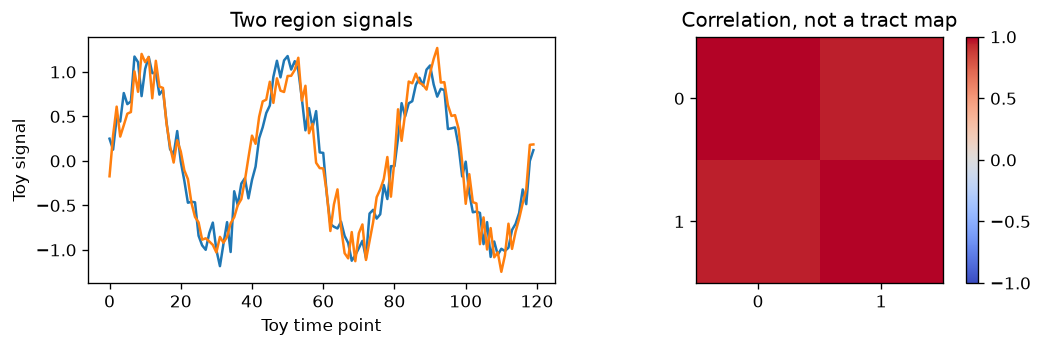

In [2]:
changed = regions.copy()
changed[:, 1] = 5*changed[:, 1] + 10
C_changed = np.corrcoef(changed, rowvar=False)
assert np.allclose(C, C_changed)
print("Positive scaling and offset preserve correlation:", np.allclose(C, C_changed))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(regions)
axes[0].set(xlabel="Toy time point", ylabel="Toy signal", title="Two region signals")
im = axes[1].imshow(C, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set(title="Correlation, not a tract map", xticks=[0,1], yticks=[0,1])
fig.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()


**Deliberate failure:** cancellation inside a region. A correct array shape does not establish a useful representation. Why can we not reconstruct both voxel values from their mean?

In [3]:
opposite_voxels = np.array([1.0, -1.0])
lost_signal = opposite_voxels.mean()
print("Original voxel values:", opposite_voxels, "regional mean:", lost_signal)
assert lost_signal == 0
print("One number cannot uniquely recover the two originals.")


Original voxel values: [ 1. -1.] regional mean: 0.0
One number cannot uniquely recover the two originals.


**Check:** shapes `(120,6) → (120,2) → (2,2)`; high off-diagonal correlation; unchanged correlation after positive scaling. Submit a transformation sketch and distinguish time points from participants. Correlation is undefined for a constant region signal.

## 2 — Regression and classification need baselines

**Input → output:** one row per toy person, three numerical features → continuous toy score or binary toy label. Scaling changes units using training estimates; prediction compresses a row to one output. No imaging or clinical claim is implied.

Predict: should a model recover the deliberately planted relationship better than a training-mean baseline?

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, balanced_accuracy_score
rng = np.random.default_rng(5502)
X = rng.normal(size=(240, 3))
y = 4*X[:, 0] - 2*X[:, 1] + rng.normal(0, 0.7, 240)
tr, te = train_test_split(np.arange(len(y)), test_size=.3, random_state=7)
baseline = DummyRegressor(strategy="mean").fit(X[tr], y[tr])
model = make_pipeline(StandardScaler(), Ridge(alpha=1)).fit(X[tr], y[tr])
base_mae = mean_absolute_error(y[te], baseline.predict(X[te]))
model_mae = mean_absolute_error(y[te], model.predict(X[te]))
print("Baseline / ridge MAE (toy-score units):", round(base_mae,3), round(model_mae,3))
assert model_mae < base_mae


Baseline / ridge MAE (toy-score units): 3.07 0.572


In [5]:
label = (2*X[:, 0] - X[:, 1] + rng.normal(0, .4, 240) > 0).astype(int)
classifier = make_pipeline(StandardScaler(), LogisticRegression()).fit(X[tr], label[tr])
dummy = DummyClassifier(strategy="most_frequent").fit(X[tr], label[tr])
score = balanced_accuracy_score(label[te], classifier.predict(X[te]))
dummy_score = balanced_accuracy_score(label[te], dummy.predict(X[te]))
print("Majority / logistic balanced accuracy:", round(dummy_score,3), round(score,3))
assert dummy_score == 0.5 and score > dummy_score
print("Three held-out probabilities:", classifier.predict_proba(X[te])[:3, 1].round(3))


Majority / logistic balanced accuracy: 0.5 0.931
Three held-out probabilities: [0.618 0.445 0.885]


**Deliberate failure:** overwrite every held-out feature with zero without changing its row count. Predict what happens before running the cell. This is destructive replacement, not a missing-data strategy.

In [6]:
destroyed = np.zeros_like(X[te])
bad_predictions = model.predict(destroyed)
print("Original and destroyed shapes:", X[te].shape, destroyed.shape)
print("Distinct destroyed-input predictions:", np.unique(bad_predictions).round(3))
print("Destroyed-input MAE:", round(mean_absolute_error(y[te], bad_predictions), 3))
assert np.ptp(bad_predictions) == 0


Original and destroyed shapes: (72, 3) (72, 3)
Distinct destroyed-input predictions: [0.055]
Destroyed-input MAE: 3.063


**Check:** ridge MAE improves on the mean baseline; the classification baseline has balanced accuracy 0.5; destroyed inputs produce one constant prediction. Explain why lower MAE on this split does not prove causation.

## 3 — Participant leakage, training-only transforms, nested tuning

**Input → output:** repeated rows plus participant IDs → disjoint participant splits → outer-fold error estimates. Group splitting prevents the same participant appearing across folds; it does not by itself establish participant independence or site generalization. No new participants are created by adding folds.

The first data have random participant labels, so their repeated fingerprints carry no generalizable relationship. Predict why a row split might nevertheless look successful.

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error
rng = np.random.default_rng(5503)
groups = np.repeat(np.arange(60), 2)
X = np.repeat(rng.normal(size=(60, 12)), 2, axis=0)
y = np.repeat(rng.integers(0, 2, 60), 2)
row_tr, row_te = train_test_split(np.arange(120), test_size=.3, random_state=4)
group_tr, group_te = next(GroupShuffleSplit(n_splits=1, test_size=.3, random_state=4).split(X, y, groups))
for name, tr, te in [("row", row_tr, row_te), ("participant", group_tr, group_te)]:
    overlap = np.intersect1d(groups[tr], groups[te]).size
    pred = KNeighborsClassifier(n_neighbors=1).fit(X[tr], y[tr]).predict(X[te])
    print(name, "overlapping participants:", overlap, "accuracy:", round(accuracy_score(y[te], pred),3))
assert np.intersect1d(groups[group_tr], groups[group_te]).size == 0


row overlapping participants: 20 accuracy: 0.889
participant overlapping participants: 0 accuracy: 0.5


**Deliberate failure:** estimate scaling from all rows. The printed parameter difference is evidence that held-out rows changed the transformation. This invalid scaler is inspected only; it is not used in the valid evaluation below.

In [8]:
invalid_scaler = StandardScaler().fit(X)
valid_scaler = StandardScaler().fit(X[group_tr])
change = np.max(np.abs(invalid_scaler.mean_ - valid_scaler.mean_))
print("Largest mean change from fitting forbidden rows:", round(change,4))
assert change > 0


Largest mean change from fitting forbidden rows: 0.2727


Now create a separate continuous toy outcome. Inner grouped folds select ridge strength; outer grouped folds evaluate the whole selection procedure. Read `groups=groups[tr]` carefully: inner tuning also needs participant groups. All scaling lives inside the fitted pipeline.

In [9]:
rng = np.random.default_rng(5533)
X_reg = np.repeat(rng.normal(size=(60, 5)), 2, axis=0)
y_reg = np.repeat(2*X_reg[::2, 0] + rng.normal(0, .5, 60), 2)
outer_scores = []
for tr, te in GroupKFold(n_splits=4).split(X_reg, y_reg, groups):
    assert np.intersect1d(groups[tr], groups[te]).size == 0
    pipeline = make_pipeline(StandardScaler(), Ridge())
    search = GridSearchCV(pipeline, {"ridge__alpha": [.1, 1, 10]},
                          cv=GroupKFold(n_splits=3), scoring="neg_mean_absolute_error")
    search.fit(X_reg[tr], y_reg[tr], groups=groups[tr])
    outer_scores.append(mean_absolute_error(y_reg[te], search.predict(X_reg[te])))
print("Four untouched outer-fold MAEs:", np.round(outer_scores, 3))
assert len(outer_scores) == 4 and np.all(np.isfinite(outer_scores))


Four untouched outer-fold MAEs: [0.345 0.696 0.363 0.433]


**Check:** participant overlap must be zero for valid splits. The random-row result may be high through memorization; exact grouped accuracy fluctuates on small data. Draw a site-held-out design separately. If a person visits two sites, prevent their cross-split overlap as well. Do not use the best inner tuning score as your final performance estimate.

## 4 — Metrics, thresholds, probabilities, and uncertainty

**Input → output:** 100 invented labels and scores → thresholded predictions → counts and summary metrics. Thresholding discards probability detail; summary metrics discard case-level detail. All predictions are constructed here; none were learned from these labels.

Predict the accuracy and recall of a classifier that says “negative” for all 100 cases, of which ten are positive.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
y = np.r_[np.zeros(90, dtype=int), np.ones(10, dtype=int)]
p = np.r_[np.full(70,.1), np.full(15,.4), np.full(5,.8), np.full(4,.4), np.full(6,.8)]
for name, pred in [("all negative", np.zeros(100, dtype=int)), ("threshold .5", p >= .5)]:
    print(name, "matrix (rows=true):\n", confusion_matrix(y, pred))
    print("accuracy, balanced accuracy, precision, recall:",
          np.round([accuracy_score(y,pred), balanced_accuracy_score(y,pred),
                    precision_score(y,pred,zero_division=0), recall_score(y,pred)], 3))
print("AUC, Brier:", round(roc_auc_score(y,p),3), round(brier_score_loss(y,p),4))
assert np.array_equal(confusion_matrix(y,p>=.5), [[85,5],[4,6]])


all negative matrix (rows=true):
 [[90  0]
 [10  0]]
accuracy, balanced accuracy, precision, recall: [0.9 0.5 0.  0. ]
threshold .5 matrix (rows=true):
 [[85  5]
 [ 4  6]]
accuracy, balanced accuracy, precision, recall: [0.91  0.772 0.545 0.6  ]
AUC, Brier: 0.928 0.0798


Threshold: 0.5 matrix: [[85, 5], [4, 6]] recall: 0.6 precision: 0.545
Threshold: 0.3 matrix: [[70, 20], [0, 10]] recall: 1.0 precision: 0.333


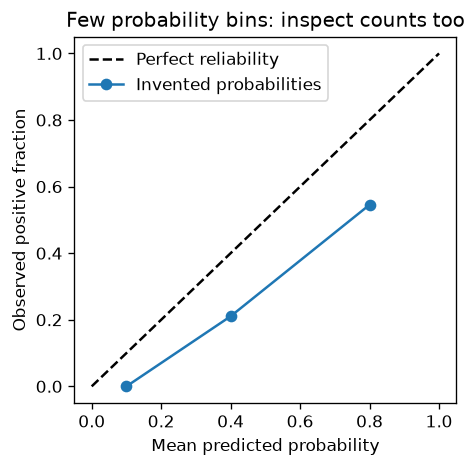

In [11]:
for threshold in [.5, .3]:
    pred = p >= threshold
    print("Threshold:", threshold, "matrix:", confusion_matrix(y,pred).tolist(),
          "recall:", recall_score(y,pred), "precision:", round(precision_score(y,pred),3))
frac_positive, mean_p = calibration_curve(y, p, n_bins=5, strategy="uniform")
plt.figure(figsize=(4,4))
plt.plot([0,1], [0,1], "k--", label="Perfect reliability")
plt.plot(mean_p, frac_positive, "o-", label="Invented probabilities")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed positive fraction")
plt.title("Few probability bins: inspect counts too")
plt.legend(); plt.tight_layout(); plt.show()


**Deliberate failure:** make scores more extreme without adding evidence. A monotonic transformation preserves ranking, so AUC is unchanged. Probability error can change. This is not a fitted calibration method.

In [12]:
extreme_p = p**5 / (p**5 + (1-p)**5)
print("Original / extreme AUC:", roc_auc_score(y,p), roc_auc_score(y,extreme_p))
print("Original / extreme Brier:", brier_score_loss(y,p), brier_score_loss(y,extreme_p))
assert np.isclose(roc_auc_score(y,p), roc_auc_score(y,extreme_p))
assert not np.isclose(brier_score_loss(y,p), brier_score_loss(y,extreme_p))


Original / extreme AUC: 0.9277777777777778 0.9277777777777778
Original / extreme Brier: 0.07980000000000001 0.08316614723051018


Illustrate sampling uncertainty by resampling these **independent toy cases**, not pixels or repeated visits. This interval conditions on the fixed predictions and does not capture training uncertainty, bias, or site shift. The tiny, invented example cannot establish clinical reliability.

In [13]:
rng = np.random.default_rng(5504)
bootstrap_scores = []
for _ in range(600):
    ix = rng.integers(0, len(y), len(y))
    if len(np.unique(y[ix])) == 2:
        bootstrap_scores.append(balanced_accuracy_score(y[ix], p[ix] >= .5))
interval = np.percentile(bootstrap_scores, [2.5,97.5])
print("Illustrative 95% bootstrap percentile interval:", np.round(interval,3))
assert len(bootstrap_scores) >= 590 and interval[0] <= interval[1]


Illustrative 95% bootstrap percentile interval: [0.608 0.934]


**Check:** at 0.5, `[[85,5],[4,6]]`, accuracy .91, recall .60, precision 6/11, balanced accuracy about .772. At .3, false positives and sensitivity both rise. Submit the metrics and describe one kind of uncertainty the bootstrap leaves out.

## 5 — Convolution, thresholding, segmentation overlap

**Input → output:** `(64,64)` toy image → blurred image → Boolean mask → Dice. Smoothing reduces local detail; thresholding removes intensity variation. The averaging kernel is hand-selected, not learned. There is no CNN training in this section.

Predict three values: deep inside the bright disk, far outside, and near its boundary.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
rng = np.random.default_rng(5505)
row, col = np.mgrid[:64, :64]
truth = (row-32)**2 + (col-32)**2 <= 12**2
image = truth.astype(float) + rng.normal(0, .15, (64,64))
kernel = np.ones((3,3))/9
blurred = convolve2d(image, kernel, mode="same", boundary="symm")
mask = blurred >= .5
print("Input, kernel, output, mask shapes:", image.shape, kernel.shape, blurred.shape, mask.shape)
assert image.shape == blurred.shape == mask.shape == (64,64)
assert mask.dtype == bool and np.isclose(kernel.sum(),1)


Input, kernel, output, mask shapes: (64, 64) (3, 3) (64, 64) (64, 64)


Toy Dice: 0.992 (both-empty convention: 1)


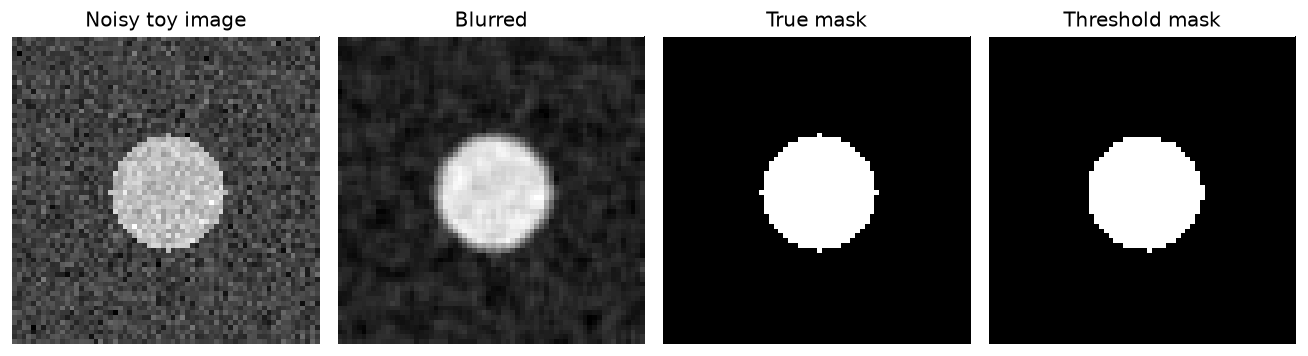

In [15]:
def dice(a, b):
    denominator = a.sum() + b.sum()
    return 1.0 if denominator == 0 else 2*np.logical_and(a,b).sum()/denominator
assert dice(truth,truth) == 1
assert dice(truth,np.zeros_like(truth)) == 0
assert dice(np.zeros_like(truth),np.zeros_like(truth)) == 1
score = dice(truth,mask)
print("Toy Dice:", round(score,3), "(both-empty convention: 1)")
fig, axes = plt.subplots(1,4,figsize=(11,3))
for ax, data, title in zip(axes,[image,blurred,truth,mask],["Noisy toy image","Blurred","True mask","Threshold mask"]):
    ax.imshow(data,cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()
assert 0 <= score <= 1


**Deliberate failure:** shift a mask without changing its shape. The zero-filled shift avoids wrapping material from one image edge to the other. Predict Dice and inspect the overlay; matching dimensions alone cannot verify physical alignment.

Aligned / shifted Dice: 0.992 0.577


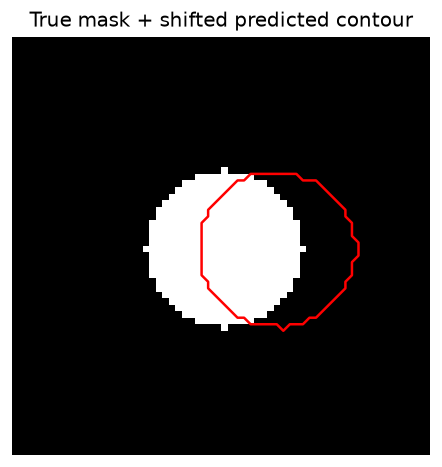

In [16]:
shifted = np.zeros_like(mask)
shifted[:, 8:] = mask[:, :-8]
shifted_score = dice(truth, shifted)
print("Aligned / shifted Dice:", round(score,3), round(shifted_score,3))
assert shifted.shape == mask.shape and shifted_score < score
plt.figure(figsize=(4,4))
plt.imshow(truth,cmap="gray")
plt.contour(shifted,levels=[.5],colors="red")
plt.title("True mask + shifted predicted contour")
plt.axis("off"); plt.tight_layout(); plt.show()


**Check:** output shape preserved, threshold mask Boolean, identical-mask Dice 1, nonempty-versus-empty Dice 0, shifted Dice lower. Explain why real 3D evaluation also needs affines, voxel sizes, orientation, per-structure performance, and overlays.

## 6 — Frozen features and a shortcut that breaks at a new site

**Input → output:** four toy features → two fixed selected features → fitted classifier probability. This encoder is a hand-designed column selection, **not** a pretrained network or execution of BrainSegFounder. No weights or model downloads occur.

One weaker feature represents a stable relationship. One strong shortcut agrees with the label during training but reverses in the shifted set. Two unused noise columns are discarded. Predict what a model will learn when the shortcut is much easier.

In [17]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
rng = np.random.default_rng(5506)
def make_toy(n, shortcut_direction=1):
    y = rng.integers(0,2,n)
    sign = 2*y-1
    stable = sign + rng.normal(0,1.2,n)
    shortcut = shortcut_direction*2.5*sign + rng.normal(0,.2,n)
    X = np.column_stack([stable, shortcut, rng.normal(size=(n,2))])
    return X, y
def frozen_encoder(X):
    return X[:, :2].copy()
Xtr,ytr = make_toy(300)
Xin,yin = make_toy(200)
Xshift,yshift = make_toy(200, shortcut_direction=-1)


In [18]:
Ztr, Zin, Zshift = [frozen_encoder(X) for X in [Xtr,Xin,Xshift]]
head = make_pipeline(StandardScaler(),LogisticRegression()).fit(Ztr,ytr)
stable_head = make_pipeline(StandardScaler(),LogisticRegression()).fit(Ztr[:,:1],ytr)
in_score = balanced_accuracy_score(yin,head.predict(Zin))
shift_score = balanced_accuracy_score(yshift,head.predict(Zshift))
stable_score = balanced_accuracy_score(yshift,stable_head.predict(Zshift[:,:1]))
print("Frozen feature shapes:", Ztr.shape,Zin.shape,Zshift.shape)
print("Full head, in-domain / shifted:", round(in_score,3),round(shift_score,3))
print("Stable-feature-only head, shifted:", round(stable_score,3))
assert np.array_equal(Ztr, frozen_encoder(Xtr))
assert in_score > .9 and shift_score < .2 and stable_score > shift_score


Frozen feature shapes: (300, 2) (200, 2) (200, 2)
Full head, in-domain / shifted: 1.0 0.0
Stable-feature-only head, shifted: 0.763


**Deliberate failure:** the shifted set reverses the shortcut while keeping array dimensions identical. Compare the full and stable-only representations before concluding that more features help. This setup demonstrates one mechanism, not a universal ranking of model sizes.

**Transfer to real work (no execution required):** Fill a model-card table with checkpoint/revision, modality, channel order, preprocessing, training population, task, code license, weight terms, and dataset conditions. Read the authors' [BrainSegFounder card](https://huggingface.co/smilelab/BrainSegFounder) and [repository](https://github.com/lab-smile/BrainSegFounder); code GPL-3.0 and UK Biobank weight conditions are distinct. Unknown fields stay unknown. Do not download or train a real model as part of this toy lab.

Explain what would change during fine-tuning: some encoder weights would be updated using training data, in addition to the head. We do not simulate that training here. Outline a participant- and site-held-out validation, compare a simple baseline, and propose a saliency randomization check. A plausible heat map is not a causal explanation or a validation result.

**Check:** the full head does well in-domain but fails under reversed shortcut; the stable-feature head transfers better in this particular toy example. Describe exactly which transforms were fixed, which were fitted, and what each discarded.